In [13]:
import json
import pandas as pd

with open('Timeline.json','r', encoding='utf-8') as data:
    datos = json.load(data)

print("Estructura principal:", datos.keys())

df=pd.json_normalize(datos['semanticSegments'])
df_visitas = df.dropna(subset=['visit.topCandidate.placeId']).copy()
df_actividades = df.dropna(subset=['activity.topCandidate.type']).copy()

print(f"Total de visitas registradas: {len(df_visitas)}")
print(f"Total de actividades registradas: {len(df_actividades)}")

display(df.head())

Estructura principal: dict_keys(['semanticSegments', 'rawSignals', 'userLocationProfile'])
Total de visitas registradas: 2998
Total de actividades registradas: 3464


,startTime,endTime,timelinePath,startTimeTimezoneUtcOffsetMinutes,endTimeTimezoneUtcOffsetMinutes,visit.hierarchyLevel,visit.probability,visit.topCandidate.placeId,visit.topCandidate.semanticType,visit.topCandidate.probability,...,activity.end.latLng,activity.distanceMeters,activity.probability,activity.topCandidate.type,activity.topCandidate.probability,activity.parking.location.latLng,activity.parking.startTime,visit.isTimelessVisit,timelineMemory.trip.distanceFromOriginKms,timelineMemory.trip.destinations
0,2025-04-04T22:00:00.000-03:00,2025-04-05T00:00:00.000-03:00,"[{'point': '-34.7173411°, -58.4094101°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-04T22:01:24.000-03:00,2025-04-06T12:01:13.000-03:00,NaN,-180.0,-180.0,0.0,0.452601,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,0.256845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-05T00:00:00.000-03:00,2025-04-05T02:00:00.000-03:00,"[{'point': '-34.7173704°, -58.4094521°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-06T12:00:00.000-03:00,2025-04-06T14:00:00.000-03:00,"[{'point': '-34.7320946°, -58.3663463°', 'time...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-06T12:01:13.000-03:00,2025-04-06T15:27:23.000-03:00,NaN,-180.0,-180.0,0.0,0.968866,ChIJ5zQgH6oyo5UR1ZFL3oUlYgc,UNKNOWN,0.375224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
import json
import pandas as pd

with open('Timeline.json','r', encoding='utf-8') as data:
    datos = json.load(data)
    print("Estructura principal:", datos.keys())

df=pd.json_normalize(datos['semanticSegments'])
df_visitas = df.dropna(subset=['visit.topCandidate.placeId']).copy()
df_actividades = df.dropna(subset=['activity.topCandidate.type']).copy()

#define una  lista con las columnas a conservar
columnas_utiles = [
    'startTime', 'endTime', 'visit.topCandidate.placeId', 'visit.topCandidate.semanticType'
]
df_visitas_util = df_visitas[columnas_utiles].copy()

df_visitas_util.columns = ['inicio', 'fin', 'place_id', 'tipo_lugar']

df_visitas_util['inicio']=pd.to_datetime(df_visitas_util['inicio'])
df_visitas_util['fin']=pd.to_datetime(df_visitas_util['fin'])

#print(df_visitas_util.dtypes)
#display(df_visitas_util.head())

#calcula la duracion de cada visita
df_visitas_util['duracion']=df_visitas_util['fin'] - df_visitas_util['inicio']

df_visitas_util['mes_anio']=df_visitas_util['inicio'].dt.to_period('M')

df_visitas_util['dia_sem']=df_visitas_util['inicio'].dt.weekday

df_visitas_util['esFinSem']=df_visitas_util['dia_sem']>=5

display(df_visitas_util.head())

Estructura principal: dict_keys(['semanticSegments', 'rawSignals', 'userLocationProfile'])


C:\Users\gabig\AppData\Local\Temp\ipykernel_2096\1816040958.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_visitas_util['mes_anio']=df_visitas_util['inicio'].dt.to_period('M')


,inicio,fin,place_id,tipo_lugar,duracion,mes_anio,dia_sem,esFinSem
1,2025-04-04 22:01:24-03:00,2025-04-06 12:01:13-03:00,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,1 days 13:59:49,2025-04,4,False
4,2025-04-06 12:01:13-03:00,2025-04-06 15:27:23-03:00,ChIJ5zQgH6oyo5UR1ZFL3oUlYgc,UNKNOWN,0 days 03:26:10,2025-04,6,True
7,2025-04-06 15:34:02-03:00,2025-04-06 17:13:53-03:00,ChIJf7aONkjNvJURrAIeUyaagWQ,UNKNOWN,0 days 01:39:51,2025-04,6,True
10,2025-04-06 17:27:37-03:00,2025-04-07 10:19:45-03:00,ChIJdRmmBA_NvJUROcvrtFw5aqI,UNKNOWN,0 days 16:52:08,2025-04,6,True
15,2025-04-09 11:43:22-03:00,2025-04-09 11:47:34-03:00,ChIJPbtP4lfKvJURDPKYCQYlUnw,WORK,0 days 00:04:12,2025-04,2,False


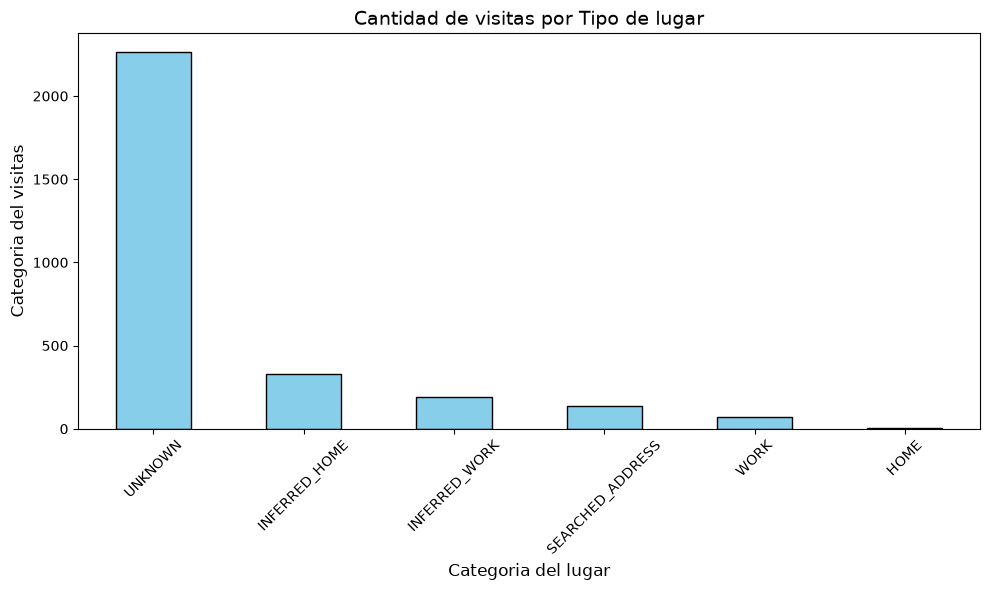

In [15]:
import matplotlib.pyplot as plt

count_lugares=df_visitas_util['tipo_lugar'].value_counts()

plt.figure(figsize=(10,6))

count_lugares.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Cantidad de visitas por Tipo de lugar', fontsize=14)
plt.xlabel('Categoria del lugar', fontsize=12)
plt.ylabel('Categoria del visitas', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()